# CREDIT RISK PREDICTION

# Import Dataset

In [ ]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [ ]:
# load dataset

#df = pd.read_csv('loan_data_2007_2014.csv')
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/vix/loan_data_2007_2014.csv')

Mounted at /content/drive


<ipython-input-2-808425107670>:6: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/vix/loan_data_2007_2014.csv')


In [ ]:
# menampilkan  5 data teratas

df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ukuran dataset

df.shape

(466285, 75)

In [ ]:
# menampilkan informasi mengenai dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

**Observasi:**
1. df merupakan data pinjaman yang diterima dan ditolak
2. df memiliki 75 kolom dan 466285 baris
3. Terdapat banyak missing values di beberapa kolom
4. Beberapa kolom hanya memiliki null values saja
5. Terdapat kesalahan data type pada beberapa kolom yang seharusnya memiliki data type datetime

# Data Cleansing

## Drop Feature with All Null Values

In [ ]:
# cek kolom yang semua nilainya adalah null

null_columns = df.columns[df.isnull().all()]
null_columns

Index(['annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
       'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
       'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl',
       'inq_last_12m'],
      dtype='object')

In [ ]:
# drop kolom null

df = df.drop(null_columns, axis=1)

## Missing Value Check

In [ ]:
# menghitung jumlah missing values setiap kolom

df.isnull().sum().sort_values(ascending=False)

mths_since_last_record         403647
mths_since_last_major_derog    367311
desc                           340302
mths_since_last_delinq         250351
next_pymnt_d                   227214
tot_cur_bal                     70276
tot_coll_amt                    70276
total_rev_hi_lim                70276
emp_title                       27588
emp_length                      21008
last_pymnt_d                      376
revol_util                        340
collections_12_mths_ex_med        145
last_credit_pull_d                 42
pub_rec                            29
inq_last_6mths                     29
delinq_2yrs                        29
open_acc                           29
earliest_cr_line                   29
acc_now_delinq                     29
total_acc                          29
title                              20
annual_inc                          4
total_rec_int                       0
total_rec_late_fee                  0
recoveries                          0
total_rec_pr

In [ ]:
# menghitung jumlah missing values setiap kolom dalam percent

null_percent = df.isnull().sum()/len(df)
null_percent.sort_values(ascending=False)

mths_since_last_record         0.865666
mths_since_last_major_derog    0.787739
desc                           0.729815
mths_since_last_delinq         0.536906
next_pymnt_d                   0.487286
tot_cur_bal                    0.150715
tot_coll_amt                   0.150715
total_rev_hi_lim               0.150715
emp_title                      0.059166
emp_length                     0.045054
last_pymnt_d                   0.000806
revol_util                     0.000729
collections_12_mths_ex_med     0.000311
last_credit_pull_d             0.000090
pub_rec                        0.000062
inq_last_6mths                 0.000062
delinq_2yrs                    0.000062
open_acc                       0.000062
earliest_cr_line               0.000062
acc_now_delinq                 0.000062
total_acc                      0.000062
title                          0.000043
annual_inc                     0.000009
total_rec_int                  0.000000
total_rec_late_fee             0.000000


In [ ]:
# Memisahkan kolom yang memiliki null values lebih dari 40% dan kurang dari 40%

null_percent_over_40 = null_percent[null_percent > 0.4].index
null_percent_under_40 = null_percent[null_percent <= 0.4].index

In [ ]:
# drop kolom yang memiliki null values lebih dari 40%

df.drop(columns = null_percent_over_40, inplace=True)

In [ ]:
# Mengisi kolom kategori yang memiliki null values kurang dari 40% dengan modus

null_cat_columns = df[null_percent_under_40].select_dtypes(include='object').columns

for col in null_cat_columns:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

In [ ]:
# Mengisi kolom numerik yang memiliki null values kurang dari 40% dengan median

null_num_columns = df[null_percent_under_40].select_dtypes(exclude='object').columns

for col in null_num_columns:
    median = df[col].median()
    df[col].fillna(median, inplace=True)

In [ ]:
# recheck missing values

df.isnull().sum()

Unnamed: 0                    0
id                            0
member_id                     0
loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
term                          0
int_rate                      0
installment                   0
grade                         0
sub_grade                     0
emp_title                     0
emp_length                    0
home_ownership                0
annual_inc                    0
verification_status           0
issue_d                       0
loan_status                   0
pymnt_plan                    0
url                           0
purpose                       0
title                         0
zip_code                      0
addr_state                    0
dti                           0
delinq_2yrs                   0
earliest_cr_line              0
inq_last_6mths                0
open_acc                      0
pub_rec                       0
revol_bal                     0
revol_ut

## Duplicated Data Check

In [ ]:
# menghitung jumlah baris yang sama

df.duplicated().sum()

0

## Date Column

In [ ]:
# mengubah data type dari object ke datetime

df[['issue_d', 'earliest_cr_line',
   'last_pymnt_d','last_credit_pull_d']] = df[['issue_d', 'earliest_cr_line',
                                                            'last_pymnt_d',
                                                            'last_credit_pull_d']].apply(pd.to_datetime, format='%b-%y')

## Define Target

In [ ]:
df['loan_status'].value_counts()

Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: loan_status, dtype: int64

In [ ]:
# mengelompokkan loan_status menjadi 2 kategori

df['loan_status'] = np.where(df['loan_status'].isin(['Charged Off', 'Late (31-120 days)', 'Late (16-30 days)',
                                                     'Default','Does not meet the credit policy. Status:Charged Off']),'bad','good')

In [ ]:
# mendefinisikan target

target = df['loan_status'].value_counts().reset_index()
target.columns = ['loan_status', 'total']
target

,loan_status,total
0,good,414099
1,bad,52186


**Observasi:**

Perlu adanya handling imbalance dataset, karena perbedaan data peminjam yang memiliki status baik (good) dengan peminjam yang memiliki status buruk (bad) sangat signifikan.

# Exploratory Data Analysis

## Categorical Variable

In [ ]:
# melihat statistical summary kolom-kolom kategorik

df.select_dtypes(include='object').describe().T

,count,unique,top,freq
term,466285,2,36 months,337953
grade,466285,7,B,136929
sub_grade,466285,35,B3,31686
emp_title,466285,205475,Teacher,32987
emp_length,466285,11,10+ years,171057
home_ownership,466285,6,MORTGAGE,235875
verification_status,466285,3,Verified,168055
loan_status,466285,2,good,414099
pymnt_plan,466285,2,n,466276
url,466285,466285,https://www.lendingclub.com/browse/loanDetail....,1


In [ ]:
df = df.drop([
    # data unik
    'Unnamed: 0', 'id', 'member_id', 'url',
    # terlalu banyak nilai unik
    'zip_code', 'emp_title', 'title', 'addr_state',
    # constant value
    'policy_code', 'application_type',
    # detail data (sudah direpresentasikan dengan kolom `grade`)
    'sub_grade',
    # imbalance
    'pymnt_plan'
    ], axis=1)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print('-----'*10)
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts())

--------------------------------------------------
Value counts for column 'term':
 36 months    337953
 60 months    128332
Name: term, dtype: int64
--------------------------------------------------
Value counts for column 'grade':
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: grade, dtype: int64
--------------------------------------------------
Value counts for column 'emp_length':
10+ years    171057
2 years       41373
3 years       36596
< 1 year      36265
5 years       30774
1 year        29622
4 years       28023
7 years       26180
6 years       26112
8 years       22395
9 years       17888
Name: emp_length, dtype: int64
--------------------------------------------------
Value counts for column 'home_ownership':
MORTGAGE    235875
RENT        188473
OWN          41704
OTHER          182
NONE            50
ANY              1
Name: home_ownership, dtype: int64
--------------------------------------------------
Value counts for column

In [ ]:
# Mengelompokkan label other, none, any pada `home ownership`

df['home_ownership'] = df['home_ownership'].replace(['OTHER', 'NONE', 'ANY'], 'OTHER')

### `term`

In [ ]:
total_term = df['term'].value_counts().reset_index()
total_term.columns = ['term', 'total']
total_term['%'] = round(total_term['total']*100/sum(total_term['total']),2)
total_term

,term,total,%
0,36 months,337953,72.48
1,60 months,128332,27.52


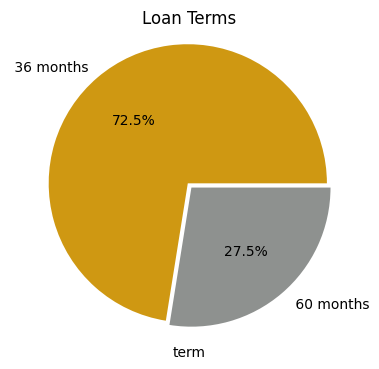

In [ ]:
# pie plot untuk `term`

plt.figure(figsize=(4,4))
explode = (0.02, 0.02)
plt.pie(total_term['total'],
        labels = total_term['term'],
        explode=explode,
        colors=['#cf9812', '#8e918f'],
        autopct='%1.1f%%')
plt.title('Loan Terms')
plt.xlabel('term')
plt.axis('equal')
plt.show()

**Observasi:**
1. 72,5% peminjam memiliki durasi pinjaman selama 3 tahun.
2. Peminjam yang melakukan pembayaran selama 3 tahun lebih banyak daripada peminjam yang melakukan pembayaran selama 5 tahun.

In [ ]:
term_by_status = df.groupby(['term','loan_status']).size().reset_index()
term_by_status.columns = ['term','loan_status', 'total']
term_by_status['%'] = round(term_by_status['total']*100/sum(term_by_status['total']),2)
term_by_status

,term,loan_status,total,%
0,36 months,bad,33579,7.20
1,36 months,good,304374,65.28
2,60 months,bad,18607,3.99
3,60 months,good,109725,23.53


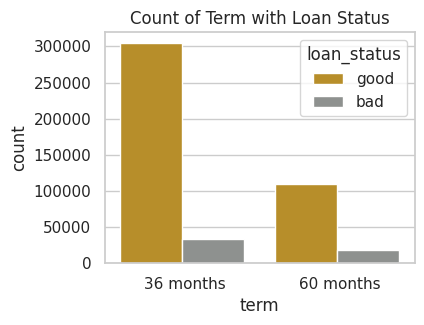

In [ ]:
# count plot `loan_status` berdasarkan `term`

plt.figure(figsize = (4,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='term',
                hue='loan_status', data=df, palette=custom_palette)
plt.xlabel('term')
plt.title('Count of Term with Loan Status')
plt.show()

**Observasi:**

1. Lebih banyak peminjam yang memiliki status baik (good) pada durasi pinjaman 3 tahun maupun 5 tahun.
2. peminjam yang memiliki status buruk (bad) lebih banyak pada durasi pinjaman 3 tahun dibandingkan dengan durasi pinjaman 5 tahun

### `grade`

In [ ]:
total_grade = df['grade'].value_counts().reset_index()
total_grade.columns = ['grade', 'total']
total_grade['%'] = round(total_grade['total']*100/sum(total_grade['total']),2)
total_grade

,grade,total,%
0,B,136929,29.37
1,C,125293,26.87
2,D,76888,16.49
3,A,74867,16.06
4,E,35757,7.67
5,F,13229,2.84
6,G,3322,0.71


<ipython-input-39-8068e7db8196>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='grade', data=df, order=order, palette=['#cf9812'])
<ipython-input-39-8068e7db8196>:6: UserWarning: 
The palette list has fewer values (1) than needed (7) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='grade', data=df, order=order, palette=['#cf9812'])


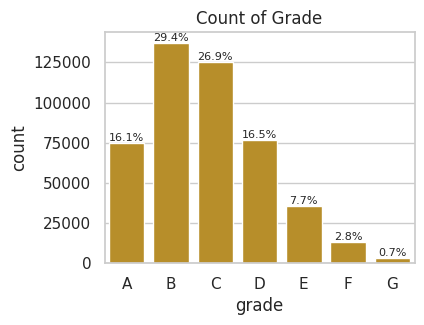

In [ ]:
# count plot untuk 'grade'

plt.figure(figsize = (4,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
order=['A','B','C','D','E','F','G']
ax=sns.countplot(x='grade', data=df, order=order, palette=['#cf9812'])

total=float(len(df))
for p in ax.patches:
    percentage = '{:.1f}%'.format(100*p.get_height()/total)
    x=p.get_x()+p.get_width()/2
    y=p.get_height()
    ax.annotate(percentage, (x,y), ha='center', va='bottom', fontsize=8)

plt.title('Count of Grade')
plt.xlabel('grade')
plt.show()

**Observasi:**
1. `grade` berisi informasi pernilaian risiko kredit yang diberikan oleh LC kepada setiap pinjaman yang disediakan.
2.  `grade` mempunyai nilai dari A hingga G, dengan grade A diberikan kepada pinjaman dengan risiko kredit yang paling rendah.
3. Pinjaman dengan grade B memiliki nilai paling tinggi yaitu 29,4%.
3. Sebanyak 29,4% dari total pinjaman memiliki tingkat keuntungan yang sedang dengan risiko yang sedang pula.

In [ ]:
grade_by_status = df.groupby(['grade','loan_status']).size().reset_index()
grade_by_status.columns = ['grade','loan_status', 'total']
grade_by_status['%'] = round(grade_by_status['total']*100/sum(grade_by_status['total']),2)
grade_by_status.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
grade,A,A,B,B,C,C,D,D,E,E,F,F,G,G
loan_status,bad,good,bad,good,bad,good,bad,good,bad,good,bad,good,bad,good
total,2955,71912,11008,125921,14743,110550,12132,64756,7139,28618,3267,9962,942,2380
%,0.63,15.42,2.36,27.01,3.16,23.71,2.6,13.89,1.53,6.14,0.7,2.14,0.2,0.51


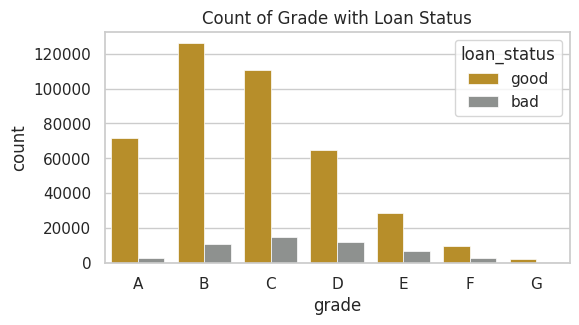

In [ ]:
# count plot `loan_status` berdasarkan 'grade'

plt.figure(figsize = (6,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
order=['A','B','C','D','E','F','G']
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='grade',
                hue='loan_status', data=df, order=order, linewidth=0.5, palette=custom_palette)
plt.xlabel('grade')
plt.title('Count of Grade with Loan Status')
plt.show()

**Observasi:**

Peminjam yang memiliki status buruk (bad) paling banyak di grade C.

### `emp_length`

In [ ]:
total_emp_length = df['emp_length'].value_counts().reset_index()
total_emp_length.columns = ['emp_length', 'total']
total_emp_length['%'] = round(total_emp_length['total']*100/sum(total_emp_length['total']),2)
total_emp_length

,emp_length,total,%
0,10+ years,171057,36.69
1,2 years,41373,8.87
2,3 years,36596,7.85
3,< 1 year,36265,7.78
4,5 years,30774,6.60
5,1 year,29622,6.35
6,4 years,28023,6.01
7,7 years,26180,5.61
8,6 years,26112,5.60
9,8 years,22395,4.80


<ipython-input-50-072aca33bc45>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='emp_length', data=df, order=order, palette=['#8e918f'])
<ipython-input-50-072aca33bc45>:9: UserWarning: 
The palette list has fewer values (1) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='emp_length', data=df, order=order, palette=['#8e918f'])


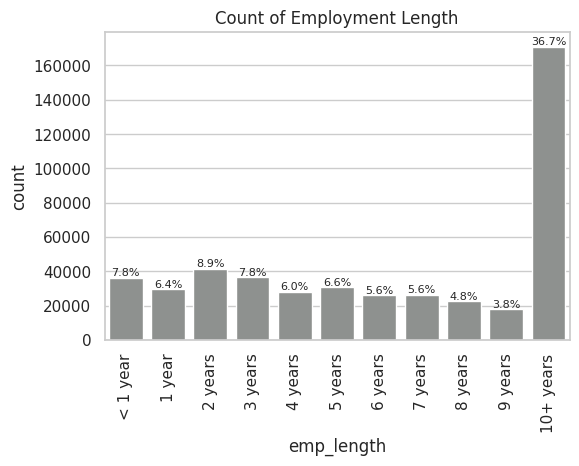

In [ ]:
# count plot untuk `emp_length`

plt.figure(figsize = (6,4))
sns.set_theme(style = 'whitegrid', context = 'notebook')
order = ['< 1 year','1 year',
         '2 years','3 years','4 years',
        '5 years','6 years','7 years',
        '8 years','9 years','10+ years']
ax=sns.countplot(x='emp_length', data=df, order=order, palette=['#8e918f'])

total=float(len(df))
for p in ax.patches:
    percentage = '{:.1f}%'.format(100*p.get_height()/total)
    x=p.get_x()+p.get_width()/2
    y=p.get_height()
    ax.annotate(percentage, (x,y), ha='center', va='bottom', fontsize=8)

plt.title('Count of Employment Length')
plt.xticks(rotation=90)
plt.xlabel('emp_length')
plt.show()

**Observation:**
1. `emp_length` berisi informasi lama masa kerja peminjam saat mengajukan pinjaman.
2. Peminjam paling banyak telah bekerja diatas 10 tahun.
3. 36,7% peminjam mempunyai lama masa kerja diatas 10 tahun. Hal ini terjadi karena semakin lama seseorang bekerja, biasanya dianggap semakin stabil secara finansial, yang dapat menjadi faktor yang menguntungkan dalam penilaian kredit.

In [ ]:
emp_length_by_status = df.groupby(['emp_length','loan_status']).size().reset_index()
emp_length_by_status.columns = ['emp_length','loan_status', 'total']
emp_length_by_status['%'] = round(emp_length_by_status['total']*100/sum(emp_length_by_status['total']),2)
emp_length_by_status

,emp_length,loan_status,total,%
0,1 year,bad,3386,0.73
1,1 year,good,26236,5.63
2,10+ years,bad,18180,3.90
3,10+ years,good,152877,32.79
4,2 years,bad,4647,1.00
5,2 years,good,36726,7.88
6,3 years,bad,4108,0.88
7,3 years,good,32488,6.97
8,4 years,bad,3151,0.68
9,4 years,good,24872,5.33


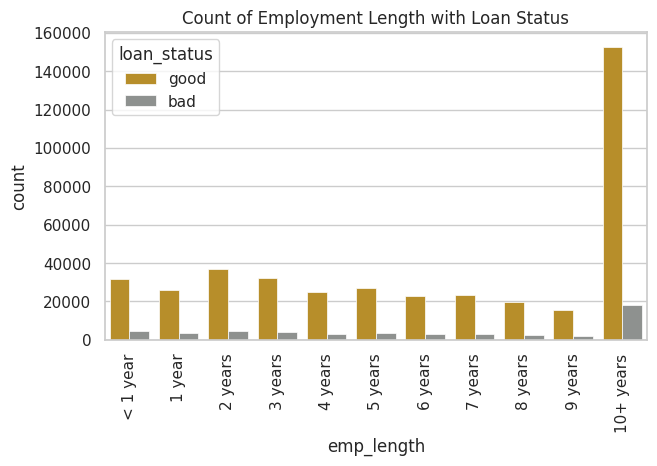

In [ ]:
# count plot `loan_status` berdasarkan `emp_length`

plt.figure(figsize = (7,4))
sns.set_theme(style = 'whitegrid', context = 'notebook')
order = ['< 1 year','1 year',
         '2 years','3 years','4 years',
        '5 years','6 years','7 years',
        '8 years','9 years','10+ years']
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='emp_length',
                hue='loan_status', data=df, order=order, linewidth=0.5, palette=custom_palette)
plt.xlabel('emp_length')
plt.xticks(rotation=90)
plt.title('Count of Employment Length with Loan Status')
plt.show()

**Observation:**

Peminjam dengan lama masa kerja lebih dari 10 tahun memiliki status baik (good) maupun status buruk (bad) paling banyak dibandingkan lama masa kerja dibawah 10 tahun.

### `home_ownership`

In [ ]:
total_home_ownership = df['home_ownership'].value_counts().reset_index()
total_home_ownership.columns = ['home_ownership', 'total']
total_home_ownership['%'] = round(total_home_ownership['total']*100/sum(total_home_ownership['total']),2)
total_home_ownership

,home_ownership,total,%
0,MORTGAGE,235875,50.59
1,RENT,188473,40.42
2,OWN,41704,8.94
3,OTHER,233,0.05


<ipython-input-57-0e3a8aee47b7>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='home_ownership', data=df, palette=['#cf9812'])
<ipython-input-57-0e3a8aee47b7>:5: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='home_ownership', data=df, palette=['#cf9812'])


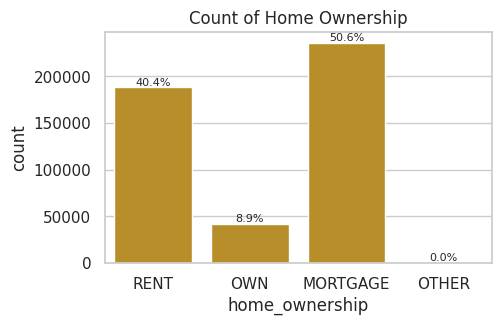

In [ ]:
# count plot untuk kolom `home_ownership`

plt.figure(figsize = (5,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(x='home_ownership', data=df, palette=['#cf9812'])

total=float(len(df))
for p in ax.patches:
    percentage = '{:.1f}%'.format(100*p.get_height()/total)
    x=p.get_x()+p.get_width()/2
    y=p.get_height()
    ax.annotate(percentage, (x,y), ha='center', va='bottom', fontsize=8)

plt.title('Count of Home Ownership')
plt.xlabel('home_ownership')
plt.show()

**Observation:**
1. `home_ownership` berisi informasi status kepemilikan tempat tinggal peminjam.
2. 50,59% peminjam memiliki rumah mortgage, yang mengindikasikan bahwa peminjam memiliki rumah tetapi masih membayar cicilan kepada lembaga keuangan yang memberikan pinjaman untuk membeli rumah tersebut.

In [ ]:
home_ownership_by_status = df.groupby(['home_ownership','loan_status']).size().reset_index()
home_ownership_by_status.columns = ['home_ownership','loan_status', 'total']
home_ownership_by_status['%'] = round(home_ownership_by_status['total']*100/sum(home_ownership_by_status['total']),2)
home_ownership_by_status

,home_ownership,loan_status,total,%
0,MORTGAGE,bad,23247,4.99
1,MORTGAGE,good,212628,45.60
2,OTHER,bad,46,0.01
3,OTHER,good,187,0.04
4,OWN,bad,4643,1.00
5,OWN,good,37061,7.95
6,RENT,bad,24250,5.20
7,RENT,good,164223,35.22


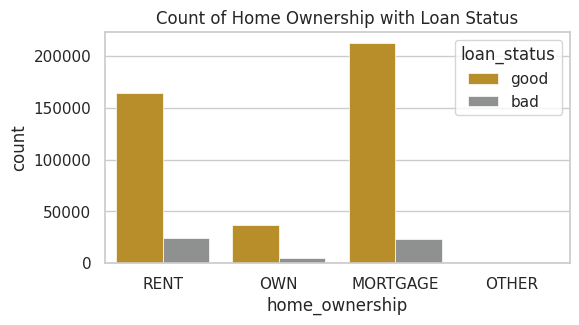

In [ ]:
# count plot `loan_status` berdasarkan `home_ownership`

plt.figure(figsize = (6,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='home_ownership',
                hue='loan_status', data=df, palette=custom_palette)
plt.xlabel('home_ownership')
plt.title('Count of Home Ownership with Loan Status')
plt.show()

**Observation:**
1. Peminjam yang menyewa rumah memiliki status buruk (bad) yang tinggi
2. Peminjam yang memiliki rumah pribadi memiliki status buruk (bad) yang rendah
3. Secara umum, peminjam dengan status baik (good) lebih banyak dibandingkan dengn peminjam dengan status buruk (bad) pada semua tipe rumah peminjam.

### `verification_status`

In [ ]:
total_verification_status = df['verification_status'].value_counts().reset_index()
total_verification_status.columns = ['verification_status', 'total']
total_verification_status['%'] = round(total_verification_status['total']*100/sum(total_verification_status['total']),2)
total_verification_status

,verification_status,total,%
0,Verified,168055,36.04
1,Source Verified,149993,32.17
2,Not Verified,148237,31.79


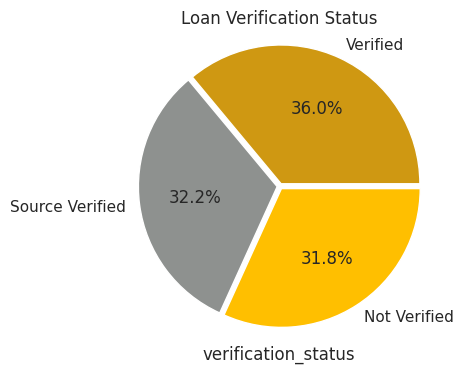

In [ ]:
# pie plot untuk `verification_status`

plt.figure(figsize=(4,4))
explode = (0.02, 0.02,0.02)
plt.pie(total_verification_status['total'],
        labels = total_verification_status['verification_status'],
        explode=explode,
        colors=['#cf9812', '#8e918f', '#ffbf00'],
        autopct='%1.1f%%')
plt.title('Loan Verification Status')
plt.xlabel('verification_status')
plt.axis('equal')
plt.show()

**Observation:**

1. 36% peminjam berstatus terverifikasi
2. 32,2% peminjam berstatus sumber terverifikasi
3. 31,8% peminjam belum terverifikasi

In [ ]:
verification_by_status = df.groupby(['verification_status','loan_status']).size().reset_index()
verification_by_status.columns = ['verification_status','loan_status', 'total']
verification_by_status['%'] = round(verification_by_status['total']*100/sum(verification_by_status['total']),2)
verification_by_status

,verification_status,loan_status,total,%
0,Not Verified,bad,14205,3.05
1,Not Verified,good,134032,28.74
2,Source Verified,bad,16090,3.45
3,Source Verified,good,133903,28.72
4,Verified,bad,21891,4.69
5,Verified,good,146164,31.35


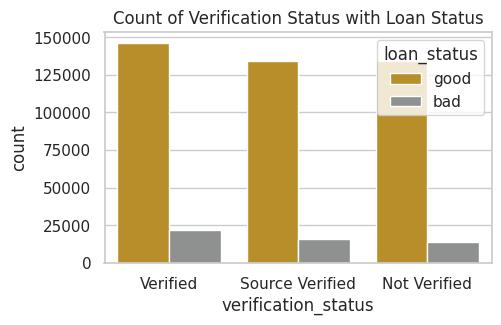

In [ ]:
# count plot `loan_status` berdasarkan `verification_status`

plt.figure(figsize = (5,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='verification_status',
                hue='loan_status', data=df, palette=custom_palette)
plt.xlabel('verification_status')
plt.title('Count of Verification Status with Loan Status')
plt.show()

**Observation:**
1. Peminjam terverifikasi mempunyai status buruk (bad) dan status baik (good) tertinggi dibandingkan lainnya.
2. Peminjam yang belum terverifikasi mempunyai status buruk (bad) dan status baik (good) terendah dibandingkan lainnya.

### `purpose`

In [ ]:
total_purpose = df['purpose'].value_counts().reset_index()
total_purpose.columns = ['purpose', 'total']
total_purpose['%']= round(total_purpose['total']*100/sum(total_purpose['total']),2)
total_purpose

,purpose,total,%
0,debt_consolidation,274195,58.80
1,credit_card,104157,22.34
2,home_improvement,26537,5.69
3,other,23690,5.08
4,major_purchase,9828,2.11
5,small_business,7013,1.50
6,car,5397,1.16
7,medical,4602,0.99
8,moving,2994,0.64
9,vacation,2487,0.53


<ipython-input-71-5ff6fcc719f5>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(y='purpose', data=df, palette=['#cf9812'])
<ipython-input-71-5ff6fcc719f5>:5: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(y='purpose', data=df, palette=['#cf9812'])


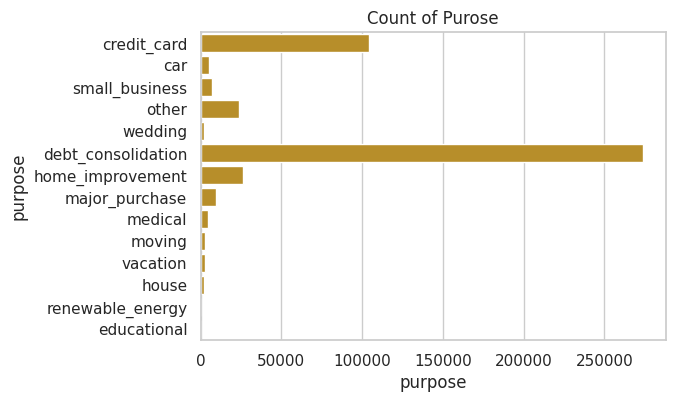

In [ ]:
# count plot untuk `purpose`

plt.figure(figsize = (6,4))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(y='purpose', data=df, palette=['#cf9812'])


plt.title('Count of Purose')
plt.xlabel('purpose')
plt.show()

**Observation:**
1. `purpose` berisi informasi alasan peminjam mengajukan pinjaman.
2. Lebih dari 50% peminjam memiliki tujuan peminjaman debt consolidation, yaitu mengambil pinjaman baru untuk membayar utang-utang.

In [ ]:
purpose_by_status = df.groupby(['purpose','loan_status']).size().reset_index()
purpose_by_status.columns = ['purpose','loan_status', 'total']
purpose_by_status['%'] = round(purpose_by_status['total']*100/sum(purpose_by_status['total']),2)
purpose_by_status

,purpose,loan_status,total,%
0,car,bad,488,0.10
1,car,good,4909,1.05
2,credit_card,bad,9200,1.97
3,credit_card,good,94957,20.36
4,debt_consolidation,bad,31836,6.83
5,debt_consolidation,good,242359,51.98
6,educational,bad,88,0.02
7,educational,good,334,0.07
8,home_improvement,bad,2672,0.57
9,home_improvement,good,23865,5.12


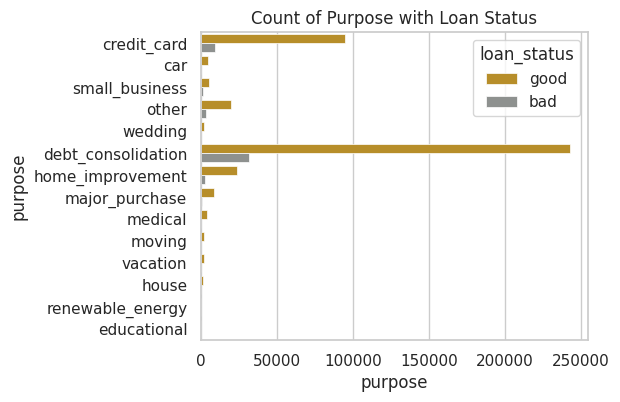

In [ ]:
# count plot `loan_status` berdasrkan `purpose`

plt.figure(figsize = (5,4))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(y='purpose',
                hue='loan_status', data=df, linewidth=0.5, palette=custom_palette)
plt.xlabel('purpose')
plt.title('Count of Purpose with Loan Status')
plt.show()

### `initial_list_status`

In [ ]:
total_initial_list_status = df['initial_list_status'].value_counts().reset_index()
total_initial_list_status.columns = ['initial_list_status', 'total']
total_initial_list_status['%'] = round(total_initial_list_status['total']*100/sum(total_initial_list_status['total']),2)
total_initial_list_status

,initial_list_status,total,%
0,f,303005,64.98
1,w,163280,35.02


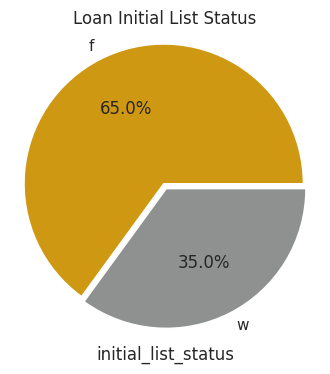

In [ ]:
# pie plot untuk `initial_list_status`

plt.figure(figsize=(4,4))
explode = (0.02, 0.02)
plt.pie(total_initial_list_status['total'],
        labels = total_initial_list_status['initial_list_status'],
        explode=explode,
        colors=['#cf9812', '#8e918f'],
        autopct='%1.1f%%')
plt.title('Loan Initial List Status')
plt.xlabel('initial_list_status')
plt.axis('equal')
plt.show()

**Observation:**
1. `initial_list_status` berisi informasi status awal penempatan pinjaman. w (whole/seluruh) atau f (fractional/sebagian).
2. 65% peminjam memiliki status awal pinjaman berupa fractional.

In [ ]:
initial_list_by_status = df.groupby(['initial_list_status','loan_status']).size().reset_index()
initial_list_by_status.columns = ['initial_list_status','loan_status', 'total']
initial_list_by_status['%'] = round(initial_list_by_status['total']*100/sum(initial_list_by_status['total']),2)
initial_list_by_status

,initial_list_status,loan_status,total,%
0,f,bad,37122,7.96
1,f,good,265883,57.02
2,w,bad,15064,3.23
3,w,good,148216,31.79


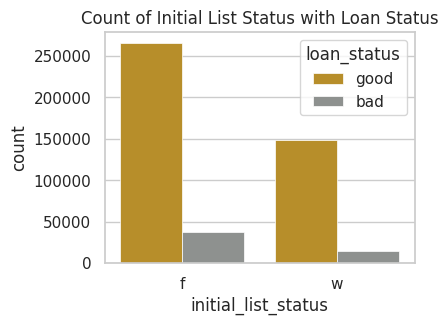

In [ ]:
# count plot `loan_status` berdasarkan `initial_list_status`

plt.figure(figsize = (4,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.countplot(x='initial_list_status',
                hue='loan_status', data=df, linewidth=0.5, palette=custom_palette)
plt.xlabel('initial_list_status')
plt.title('Count of Initial List Status with Loan Status')
plt.show()

**Observation:**

Peminjam dengan status buruk (bad) lebih banyak pada status awal pinjaman berupa fractional.


## Numerical Variable

In [ ]:
# melihat statistical summary kolom-kolom numerik

df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,466285.0,14317.277577,8286.509164,500.00,8000.000000,12000.000000,20000.00000,3.500000e+04
funded_amnt,466285.0,14291.801044,8274.371300,500.00,8000.000000,12000.000000,20000.00000,3.500000e+04
funded_amnt_inv,466285.0,14222.329888,8297.637788,0.00,8000.000000,12000.000000,19950.00000,3.500000e+04
int_rate,466285.0,13.829236,4.357587,5.42,10.990000,13.660000,16.49000,2.606000e+01
installment,466285.0,432.061201,243.485550,15.67,256.690000,379.890000,566.58000,1.409990e+03
annual_inc,466285.0,73277.293307,54963.341145,1896.00,45000.000000,63000.000000,88953.00000,7.500000e+06
dti,466285.0,17.218758,7.851121,0.00,11.360000,16.870000,22.78000,3.999000e+01
delinq_2yrs,466285.0,0.284661,0.797343,0.00,0.000000,0.000000,0.00000,2.900000e+01
inq_last_6mths,466285.0,0.804695,1.091583,0.00,0.000000,0.000000,1.00000,3.300000e+01
open_acc,466285.0,11.186995,4.987380,0.00,8.000000,10.000000,14.00000,8.400000e+01


In [ ]:
num = df.select_dtypes(include='number').columns
num

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim'],
      dtype='object')

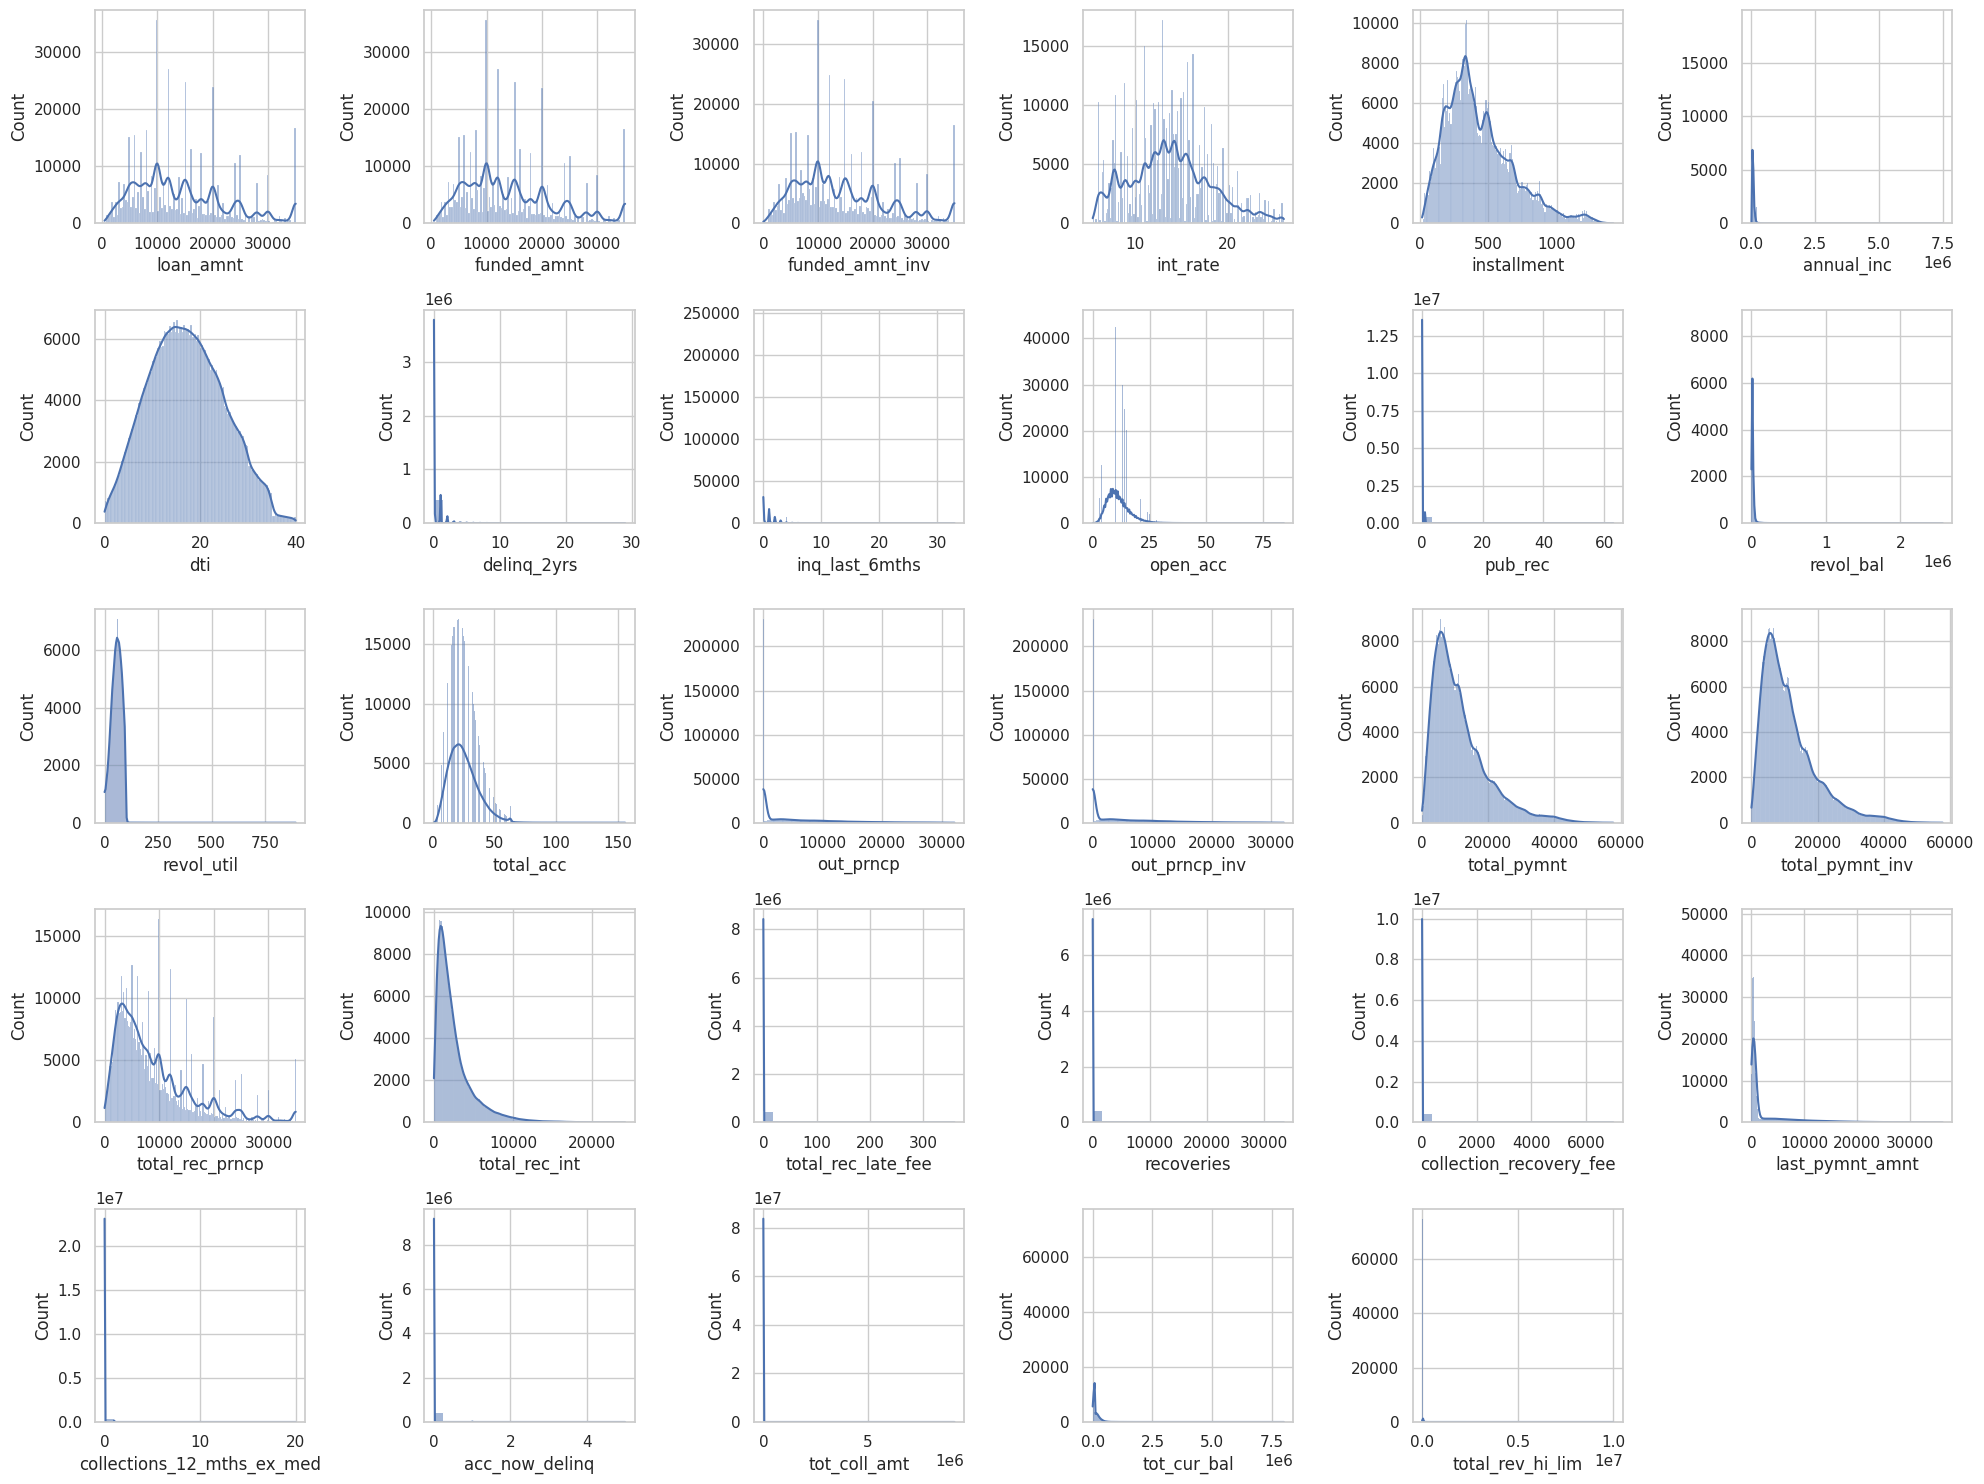

In [ ]:
# kde plot semua kolom numerik

plt.figure(figsize=(20,15))
for i in range(0, len(num)):
    plt.subplot(5, 6, i+1)
    sns.histplot(df[num[i]], kde=True)
    plt.xlabel(num[i])
plt.tight_layout()
plt.show()

<ipython-input-91-22cf918e78c7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[num[i]], y=df['loan_status'], palette=custom_palette)
<ipython-input-91-22cf918e78c7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[num[i]], y=df['loan_status'], palette=custom_palette)
<ipython-input-91-22cf918e78c7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[num[i]], y=df['loan_status'], palette=custom_palette)
<ipython-input-91-22cf918e78c7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

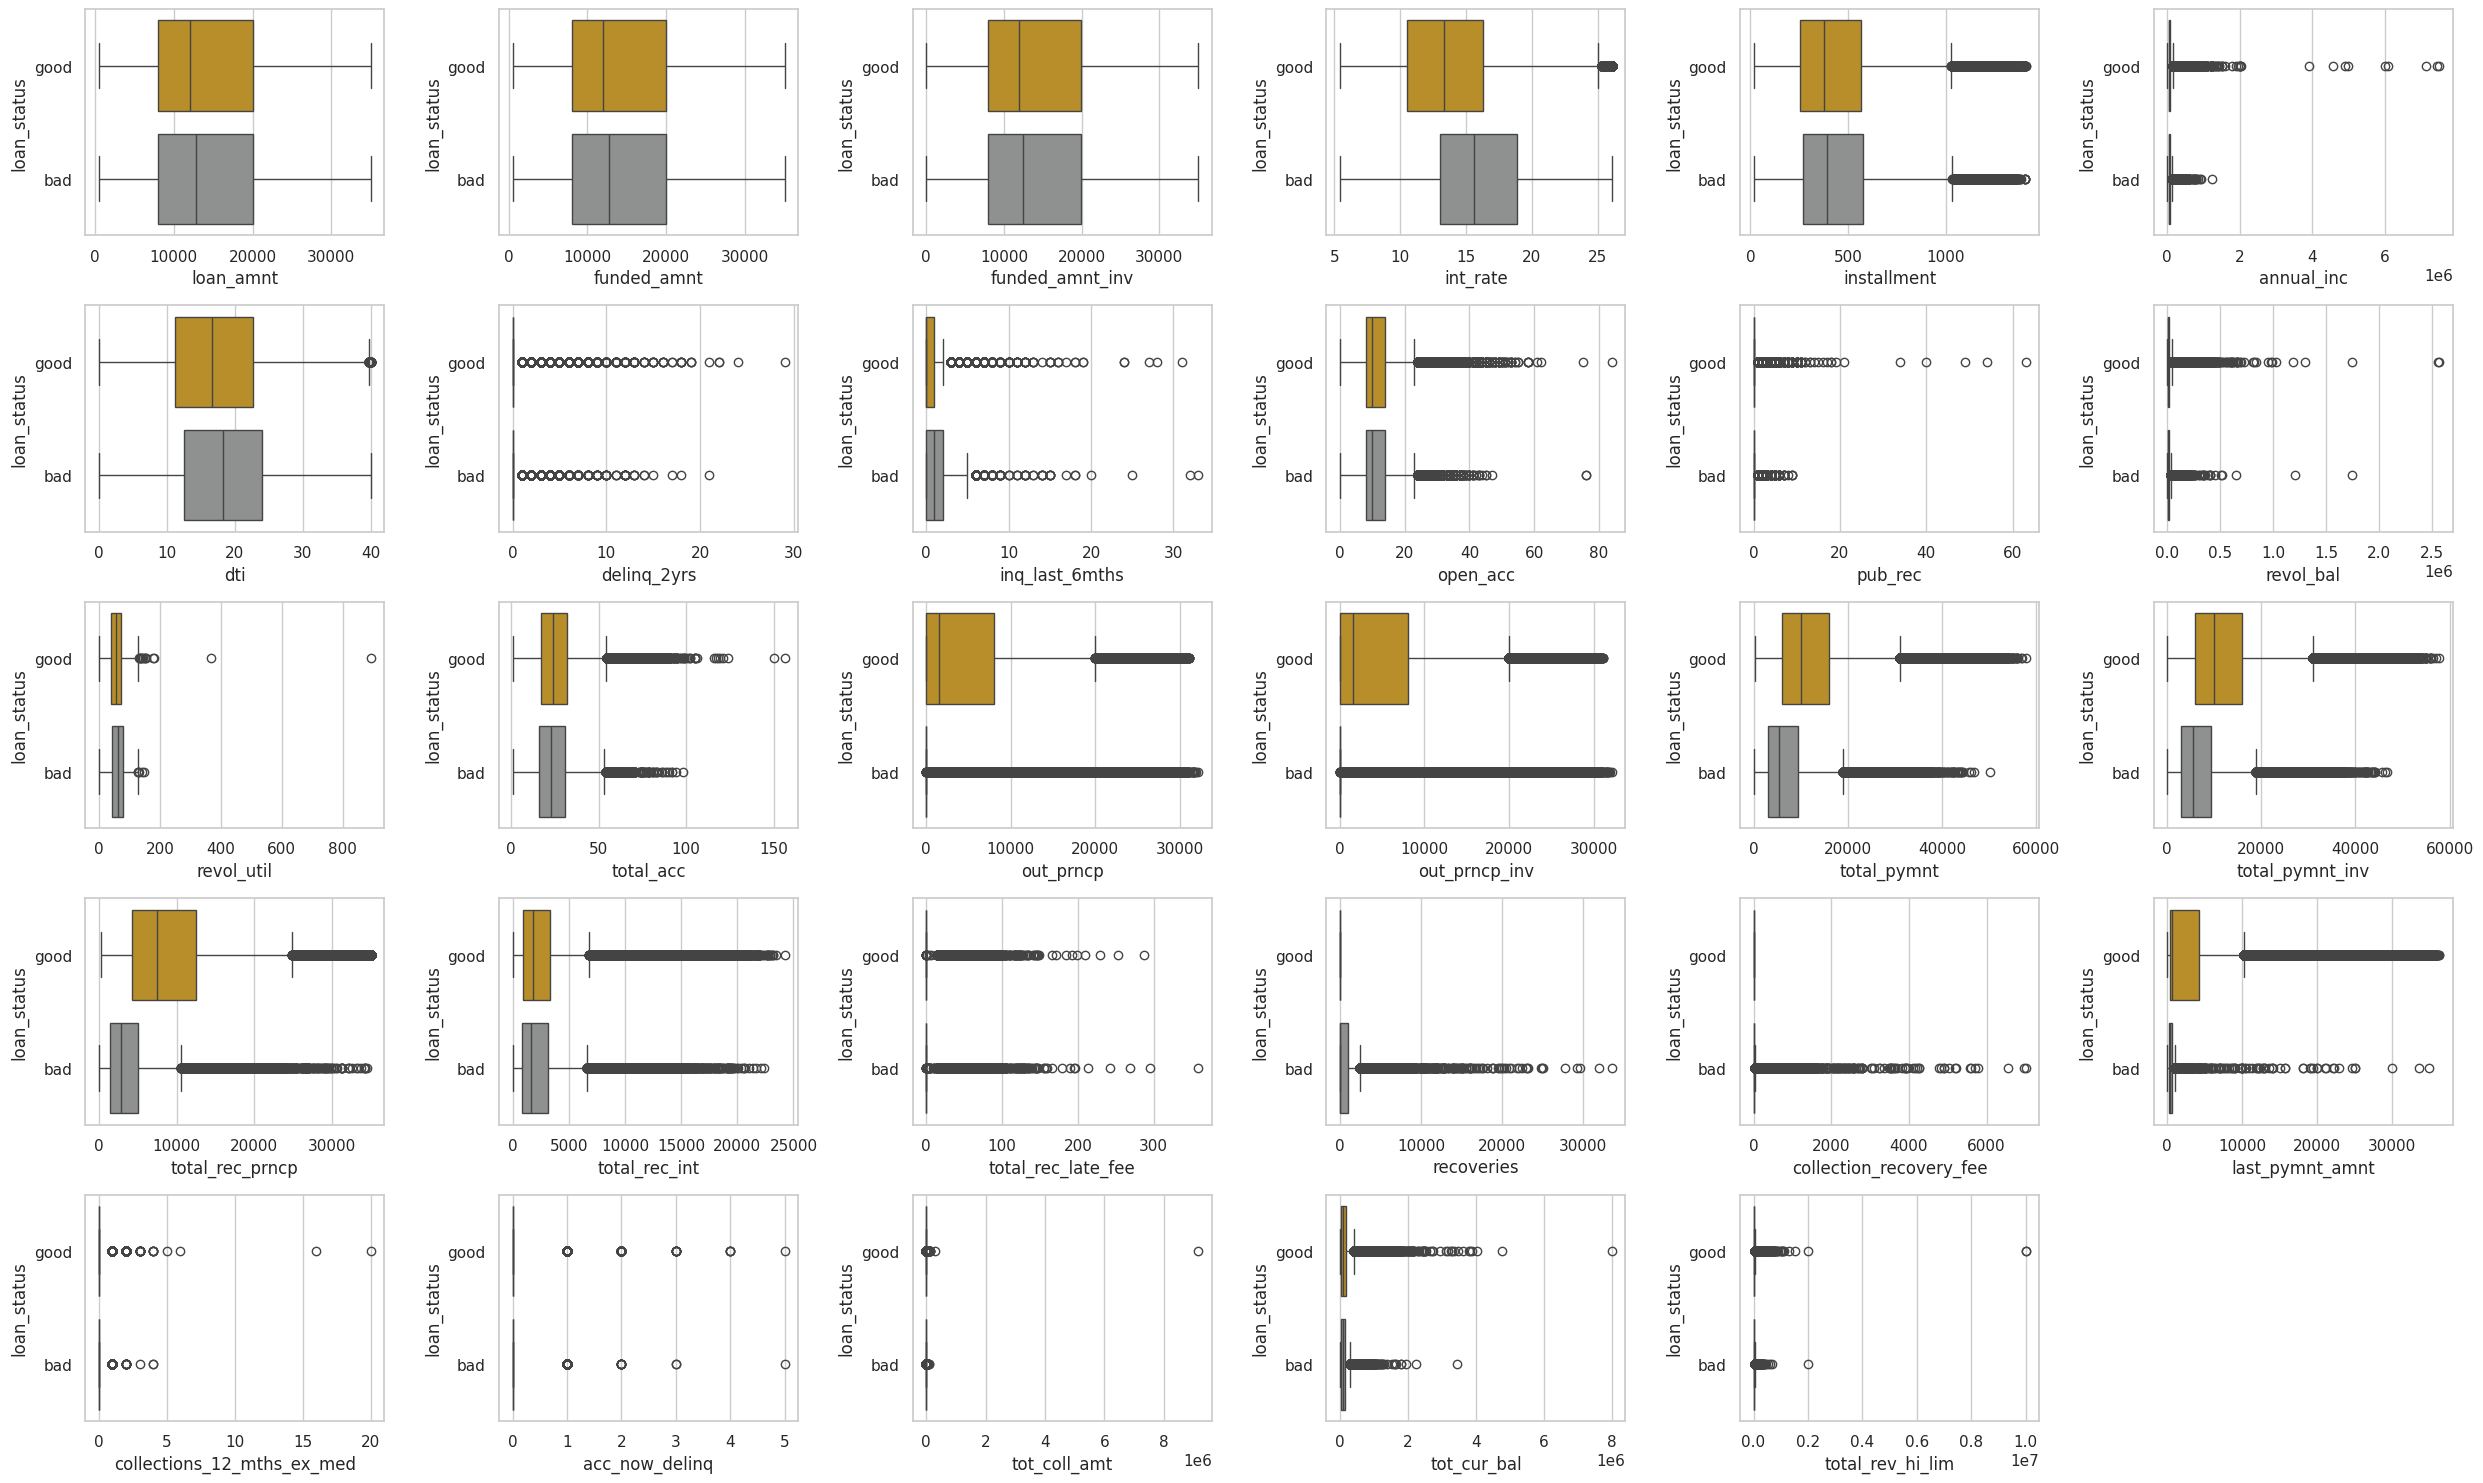

In [ ]:
# box plot semua kolom numerik

plt.figure(figsize=(25,15))
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
for i in range(0, len(num)):
    plt.subplot(5, 6, i+1)
    sns.boxplot(x = df[num[i]], y=df['loan_status'], palette=custom_palette)
    plt.xlabel(num[i])
plt.tight_layout()
plt.show()

## Time Series

### `issue_d`

In [ ]:
df['issue_d_year'] = df['issue_d'].dt.year

In [ ]:
total_issue_d_year = df['issue_d_year'].value_counts().reset_index()
total_issue_d_year.columns = ['issue_d_year', 'total']
total_issue_d_year['%'] = round(total_issue_d_year['total']*100/sum(total_issue_d_year['total']),2)
total_issue_d_year

,issue_d_year,total,%
0,2014,235628,50.53
1,2013,134755,28.90
2,2012,53367,11.45
3,2011,21721,4.66
4,2010,12537,2.69
5,2009,5281,1.13
6,2008,2393,0.51
7,2007,603,0.13


<ipython-input-105-d28b693a1079>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='issue_d_year', data=df, palette=['#8e918f'])
<ipython-input-105-d28b693a1079>:3: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='issue_d_year', data=df, palette=['#8e918f'])


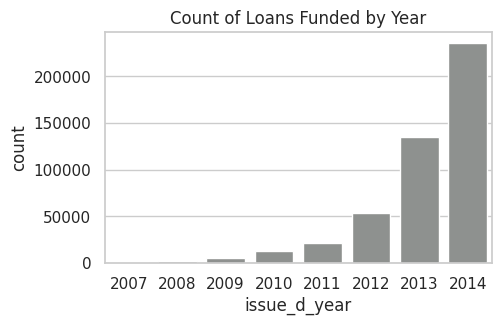

In [ ]:
plt.figure(figsize = (5,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(x='issue_d_year', data=df, palette=['#8e918f'])

plt.title('Count of Loans Funded by Year')
plt.xlabel('issue_d_year')
plt.show()

**Observation:**
1. `issue_d_year` berisi informasi tahun ketika dana pinjaman disetujui dan diberikan kepada peminjam.
2. Semakin lama, semakin tinggi jumlah peminjam.

In [ ]:
issue_d_year_by_status = df.groupby(['issue_d_year','loan_status']).size().reset_index()
issue_d_year_by_status.columns = ['issue_d_year','loan_status', 'total']
issue_d_year_by_status['%'] = round(issue_d_year_by_status['total']*100/sum(issue_d_year_by_status['total']),2)
issue_d_year_by_status

,issue_d_year,loan_status,total,%
0,2007,bad,158,0.03
1,2007,good,445,0.10
2,2008,bad,496,0.11
3,2008,good,1897,0.41
4,2009,bad,723,0.16
5,2009,good,4558,0.98
6,2010,bad,1761,0.38
7,2010,good,10776,2.31
8,2011,bad,3270,0.70
9,2011,good,18451,3.96


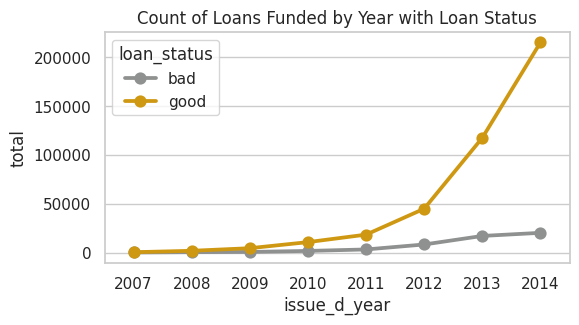

In [ ]:
plt.figure(figsize = (6,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.pointplot(x='issue_d_year', y='total',
                hue='loan_status', data=issue_d_year_by_status, palette=custom_palette)
plt.xlabel('issue_d_year')
plt.title('Count of Loans Funded by Year with Loan Status')
plt.show()

**Observasi:**

Peminjam dengan status baik (good) selalu bertambah setiap tahunnya. Terdapat kenaikan yang signifikan pada tahun 2012-2014.

### `earliest_cr_line`

In [ ]:
df['earliest_cr_line_year'] = df['earliest_cr_line'].dt.year

In [ ]:
total_earliest_cr_line_year = df['earliest_cr_line_year'].value_counts().reset_index()
total_earliest_cr_line_year.columns = ['earliest_cr_line_year', 'total']
total_earliest_cr_line_year['%'] = round(total_earliest_cr_line_year['total']*100/sum(total_earliest_cr_line_year['total']),2)
total_earliest_cr_line_year

,earliest_cr_line_year,total,%
0,2000,35568,7.63
1,2001,34233,7.34
2,1999,32477,6.97
3,2002,28999,6.22
4,1998,27919,5.99
...,...,...,...
60,2051,3,0.00
61,2046,2,0.00
62,2049,1,0.00
63,2044,1,0.00


<ipython-input-110-8fb7ad995ac6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='earliest_cr_line_year', data=df, palette=['#cf9812'])
<ipython-input-110-8fb7ad995ac6>:3: UserWarning: 
The palette list has fewer values (1) than needed (65) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='earliest_cr_line_year', data=df, palette=['#cf9812'])


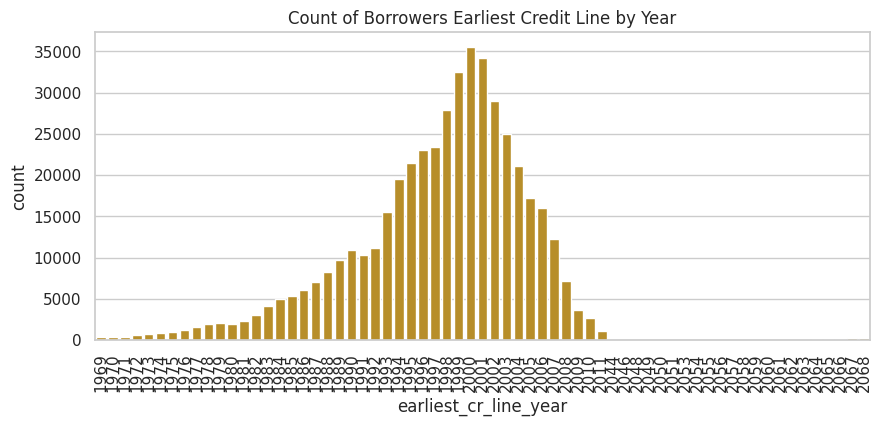

In [ ]:
plt.figure(figsize = (10,4))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(x='earliest_cr_line_year', data=df, palette=['#cf9812'])

plt.title('Count of Borrowers Earliest Credit Line by Year')
plt.xticks(rotation=90)
plt.xlabel('earliest_cr_line_year')
plt.show()

In [ ]:
earliest_cr_line_year_by_status = df.groupby(['earliest_cr_line_year','loan_status']).size().reset_index()
earliest_cr_line_year_by_status.columns = ['earliest_cr_line_year','loan_status', 'total']
earliest_cr_line_year_by_status['%'] = round(earliest_cr_line_year_by_status['total']*100/sum(earliest_cr_line_year_by_status['total']),2)
earliest_cr_line_year_by_status

,earliest_cr_line_year,loan_status,total,%
0,1969,bad,36,0.01
1,1969,good,335,0.07
2,1970,bad,48,0.01
3,1970,good,379,0.08
4,1971,bad,43,0.01
...,...,...,...,...
116,2066,good,146,0.03
117,2067,bad,42,0.01
118,2067,good,215,0.05
119,2068,bad,25,0.01


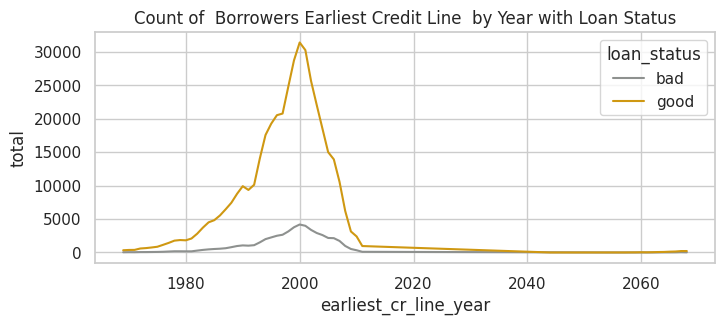

In [ ]:
plt.figure(figsize = (8,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.lineplot(x='earliest_cr_line_year', y='total',
                hue='loan_status', data=earliest_cr_line_year_by_status, palette=custom_palette)
plt.xlabel('earliest_cr_line_year')
plt.title('Count of  Borrowers Earliest Credit Line  by Year with Loan Status')
plt.show()

### `last_pymnt_d`

In [ ]:
df['last_pymnt_d_year'] = df['last_pymnt_d'].dt.year

In [ ]:
total_last_pymnt_d_year = df['last_pymnt_d_year'].value_counts().reset_index()
total_last_pymnt_d_year.columns = ['last_pymnt_d_year', 'total']
total_last_pymnt_d_year['%'] = round(total_last_pymnt_d_year['total']*100/sum(total_last_pymnt_d_year['total']),2)
total_last_pymnt_d_year

,last_pymnt_d_year,total,%
0,2016,179996,38.60
1,2015,171344,36.75
2,2014,66595,14.28
3,2013,27194,5.83
4,2012,11813,2.53
5,2011,5748,1.23
6,2010,2420,0.52
7,2009,838,0.18
8,2008,335,0.07
9,2007,2,0.00


<ipython-input-118-e05293ece8d7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='last_pymnt_d_year', data=df, palette=['#8e918f'])
<ipython-input-118-e05293ece8d7>:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='last_pymnt_d_year', data=df, palette=['#8e918f'])


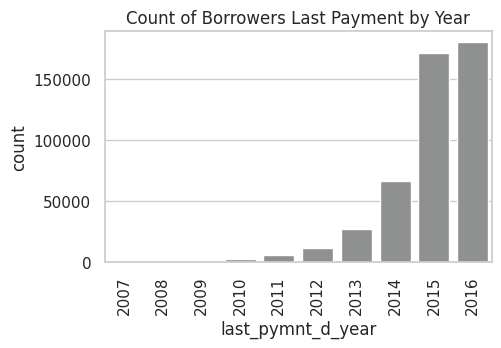

In [ ]:
plt.figure(figsize = (5,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(x='last_pymnt_d_year', data=df, palette=['#8e918f'])

plt.title('Count of Borrowers Last Payment by Year')
plt.xticks(rotation=90)
plt.xlabel('last_pymnt_d_year')
plt.show()

**Observation:**
1. `last_pymnt_d_year` berisi informasi tahun terakhir peminjam telah melakukan pembayaran untuk pinjaman tersebut.
2. semakin lama, semakin banyak peminjam yang melakukan pembayaran. Hal ini didukung data sebelumnya yang menyatakan semakin lama, semakin banyak juga yang melakukan pinjaman.

In [ ]:
last_pymnt_d_year_by_status = df.groupby(['last_pymnt_d_year','loan_status']).size().reset_index()
last_pymnt_d_year_by_status.columns = ['last_pymnt_d_year','loan_status', 'total']
last_pymnt_d_year_by_status['%'] = round(last_pymnt_d_year_by_status['total']*100/sum(last_pymnt_d_year_by_status['total']),2)
last_pymnt_d_year_by_status

,last_pymnt_d_year,loan_status,total,%
0,2007,bad,1,0.00
1,2007,good,1,0.00
2,2008,bad,185,0.04
3,2008,good,150,0.03
4,2009,bad,389,0.08
5,2009,good,449,0.10
6,2010,bad,680,0.15
7,2010,good,1740,0.37
8,2011,bad,1189,0.25
9,2011,good,4559,0.98


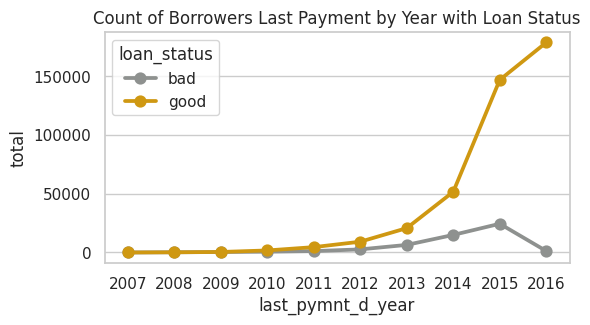

In [ ]:
plt.figure(figsize = (6,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.pointplot(x='last_pymnt_d_year', y='total',
                hue='loan_status', data=last_pymnt_d_year_by_status, palette=custom_palette)
plt.xlabel('last_pymnt_d_year')
plt.title('Count of Borrowers Last Payment by Year with Loan Status')
plt.show()

**Observation:**

Terdapat penurunan peminjam dengan status buruk (bad) pada tahun 2015-2016.

### `last_credit_pull_d`

In [ ]:
df['last_credit_pull_d_year'] = df['last_credit_pull_d'].dt.year

In [ ]:
total_last_credit_pull_d_year = df['last_credit_pull_d_year'].value_counts().reset_index()
total_last_credit_pull_d_year.columns = ['last_credit_pull_d_year', 'total']
total_last_credit_pull_d_year['%'] = round(total_last_credit_pull_d_year['total']*100/sum(total_last_credit_pull_d_year['total']),2)
total_last_credit_pull_d_year

,last_credit_pull_d_year,total,%
0,2016,327741,70.29
1,2015,85024,18.23
2,2014,31403,6.73
3,2013,12448,2.67
4,2012,5313,1.14
5,2011,2691,0.58
6,2010,1151,0.25
7,2009,394,0.08
8,2008,62,0.01
9,2007,58,0.01


<ipython-input-131-26375d00ea2b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='last_credit_pull_d_year', data=df, palette=['#cf9812'])
<ipython-input-131-26375d00ea2b>:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(x='last_credit_pull_d_year', data=df, palette=['#cf9812'])


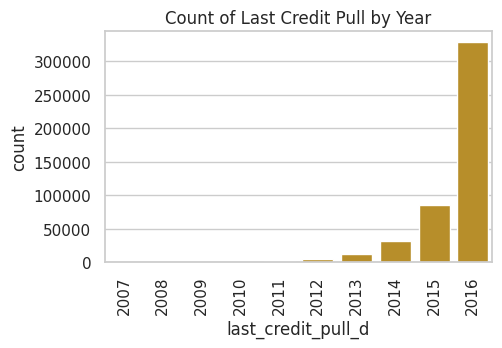

In [ ]:
plt.figure(figsize = (5,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
ax=sns.countplot(x='last_credit_pull_d_year', data=df, palette=['#cf9812'])

plt.title('Count of Last Credit Pull by Year')
plt.xticks(rotation=90)
plt.xlabel('last_credit_pull_d')
plt.show()

In [ ]:
last_credit_pull_d_year_by_status = df.groupby(['last_credit_pull_d_year','loan_status']).size().reset_index()
last_credit_pull_d_year_by_status.columns = ['last_credit_pull_d_year','loan_status', 'total']
last_credit_pull_d_year_by_status['%'] = round(last_credit_pull_d_year_by_status['total']*100/sum(last_credit_pull_d_year_by_status['total']),2)
last_credit_pull_d_year_by_status

,last_credit_pull_d_year,loan_status,total,%
0,2007,bad,1,0.00
1,2007,good,57,0.01
2,2008,bad,1,0.00
3,2008,good,61,0.01
4,2009,bad,152,0.03
5,2009,good,242,0.05
6,2010,bad,241,0.05
7,2010,good,910,0.20
8,2011,bad,469,0.10
9,2011,good,2222,0.48


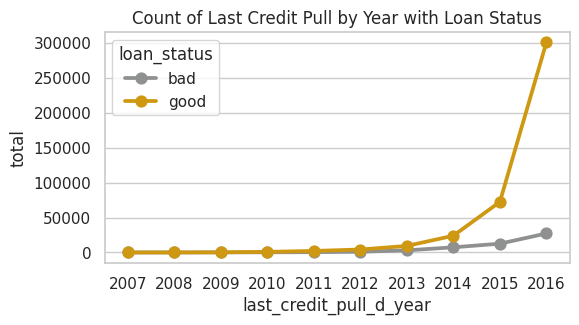

In [ ]:
plt.figure(figsize = (6,3))
sns.set_theme(style = 'whitegrid', context = 'notebook')
custom_palette = {'good':'#cf9812',
                  'bad':'#8e918f'}
ax=sns.pointplot(x='last_credit_pull_d_year', y='total',
                hue='loan_status', data=last_credit_pull_d_year_by_status, palette=custom_palette)
plt.xlabel('last_credit_pull_d_year')
plt.title('Count of Last Credit Pull by Year with Loan Status')
plt.show()

In [ ]:
df=df.drop(['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d'], axis=1)

# Data Preprocessing

## Encoding

In [ ]:
map_grade = {'A':6,'B':5,'C':4,'D':3,'E':2,'F':1,'G':0}
df['map_grade'] = df['grade'].map(map_grade)
df[['grade','map_grade']].drop_duplicates()

,grade,map_grade
0,B,5
1,C,4
5,A,6
7,E,2
8,F,1
15,D,3
223,G,0


In [ ]:
map_emp_length = {'< 1 year' :0,'1 year':1,
         '2 years':2,'3 years':3,'4 years':4,
        '5 years':5,'6 years':6,'7 years':7,
        '8 years':8,'9 years':9,'10+ years':10}
df['map_emp_length'] = df['emp_length'].map(map_emp_length)
df[['emp_length','map_emp_length']].drop_duplicates()

,emp_length,map_emp_length
0,10+ years,10
1,< 1 year,0
4,1 year,1
5,3 years,3
6,8 years,8
7,9 years,9
8,4 years,4
10,5 years,5
19,6 years,6
25,2 years,2


In [ ]:
le = preprocessing.LabelEncoder()
le.fit(df['loan_status'])
df['loan_status_le'] = le.transform(df['loan_status'])
df[['loan_status','loan_status_le']].drop_duplicates()

,loan_status,loan_status_le
0,good,1
1,bad,0


In [ ]:
le = preprocessing.LabelEncoder()
le.fit(df['term'])
df['term_le'] = le.transform(df['term'])
df[['term','term_le']].drop_duplicates()

,term,term_le
0,36 months,0
1,60 months,1


In [ ]:
le = preprocessing.LabelEncoder()
le.fit(df['initial_list_status'])
df['initial_list_status_le'] = le.transform(df['initial_list_status'])
df[['initial_list_status','initial_list_status_le']].drop_duplicates()

,initial_list_status,initial_list_status_le
0,f,0
42535,w,1


In [ ]:
df=df.drop(['term', 'grade', 'emp_length', 'initial_list_status','loan_status'], axis=1)

In [ ]:
to_ohe = ['home_ownership', 'verification_status', 'purpose']
for cat in to_ohe:
    ohe = pd.get_dummies(df[cat], prefix=cat)
    df = df.join(ohe)

In [ ]:
df.drop(columns=to_ohe, inplace=True)

## Standardization

In [ ]:
X = df.drop(['loan_status_le'],axis = 1)
y = df['loan_status_le']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X= pd.DataFrame(X, columns=df.drop(['loan_status_le'], axis=1).columns)
X.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,-1.124392,-1.122963,-1.114455,-0.729587,-1.105575,-0.896549,1.328632,-0.357012,0.178920,-1.641544,...,-0.245654,-0.069928,-0.146735,-0.099839,-0.080389,-0.231355,-0.027447,-0.123571,-0.073227,-0.071065
1,-1.426088,-1.425101,-1.412732,0.330634,-1.528763,-0.787386,-2.065791,-0.357012,3.843328,-1.641544,...,-0.245654,-0.069928,-0.146735,-0.099839,-0.080389,-0.231355,-0.027447,-0.123571,-0.073227,-0.071065
2,-1.438156,-1.437186,-1.424784,0.488979,-1.428140,-1.110292,-1.082491,-0.357012,1.095022,-1.842050,...,-0.245654,-0.069928,-0.146735,-0.099839,-0.080389,-0.231355,-0.027447,8.092507,-0.073227,-0.071065
3,-0.521001,-0.518687,-0.508860,-0.077850,-0.380931,-0.438061,0.354248,-0.357012,0.178920,-0.238000,...,-0.245654,-0.069928,-0.146735,-0.099839,-0.080389,4.322358,-0.027447,-0.123571,-0.073227,-0.071065
4,-1.365749,-1.364673,-1.352474,-0.261438,-1.496071,0.122313,0.091865,-0.357012,-0.737182,0.764532,...,-0.245654,-0.069928,-0.146735,-0.099839,-0.080389,4.322358,-0.027447,-0.123571,-0.073227,-0.071065


## Handling Imbalance Dataset

In [ ]:
from imblearn import over_sampling

X_smote, y_smote = over_sampling.SMOTE().fit_resample(X, y)

## Split Data

In [ ]:
X_smote_train, X_smote_test, y_smote_train, y_smote_test = train_test_split(X_smote, y_smote, test_size = 0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Modelling

In [ ]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score, f1_score, accuracy_score, confusion_matrix
def report(model, y_test, y_pred, model_name):
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results = pd.DataFrame({'model': [model_name],
                           'recall': [recall],
                           'precision':[precision],
                           'accuracy':[accuracy],
                           'roc_auc':[roc_auc],
                           'f1':[f1]})

    return results

## Logistic Regression

### Without SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression

a1 = 'Logistic Regression'
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logreg_report = report(logreg, y_test, y_pred_logreg, a1)

### With SMOTE

In [ ]:
a2 = 'Logistic Regression with SMOTE'

logreg2 = LogisticRegression(random_state=42)
logreg2.fit(X_smote_train, y_smote_train)
y_smote_pred_logreg = logreg2.predict(X_smote_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logreg_smote_report = report(logreg2, y_smote_test, y_smote_pred_logreg, a2)

## Random Forest

### Without SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier

b1 = 'Random Forest'
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
rf_report = report(rf, y_test, y_pred_rf, b1)

### With SMOTE

In [ ]:
b2 = 'Random Forest with SMOTE'
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X_smote_train, y_smote_train)
y_smote_pred_rf = rf2.predict(X_smote_test)

In [ ]:
rf_smote_report = report(rf2, y_smote_test, y_smote_pred_rf, b2)

## XGB

### Without SMOTE

In [ ]:
from xgboost import XGBClassifier

c1 = 'XGBClassifier'
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
xgb_report = report(xgb, y_test, y_pred_xgb, c1)

### With SMOTE

In [ ]:
c2 = 'XGBClassifier with SMOTE'
xgb2 = XGBClassifier(random_state=42)
xgb2.fit(X_smote_train, y_smote_train)
y_smote_pred_xgb = xgb2.predict(X_smote_test)

In [ ]:
xgb_smote_report = report(xgb2, y_smote_test, y_smote_pred_xgb, c2)

# Metric Evaluation

In [ ]:
result = pd.concat([logreg_report, logreg_smote_report,
                   rf_report, rf_smote_report,
                   xgb_report, xgb_smote_report])
result

,model,recall,precision,accuracy,roc_auc,f1
0,Logistic Regression,0.998418,0.977449,0.978136,0.907716,0.987822
0,Logistic Regression with SMOTE,0.969790,0.920117,0.942888,0.942931,0.944301
0,Random Forest,0.999288,0.980037,0.981288,0.918796,0.989569
0,Random Forest with SMOTE,0.993578,0.987108,0.990316,0.990322,0.990333
0,XGBClassifier,0.998575,0.982550,0.982983,0.928846,0.990498
0,XGBClassifier,0.998355,0.980917,0.989483,0.989497,0.989559


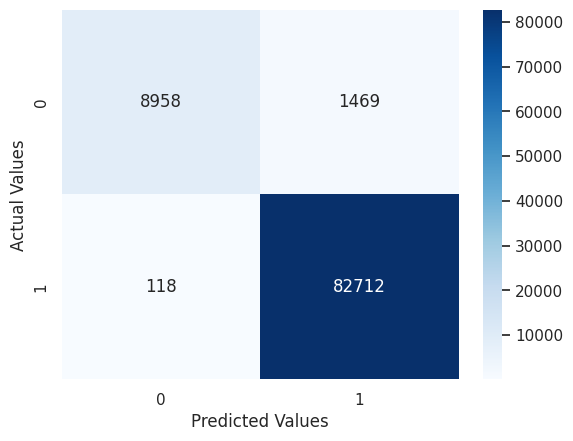

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

# Feature Importance

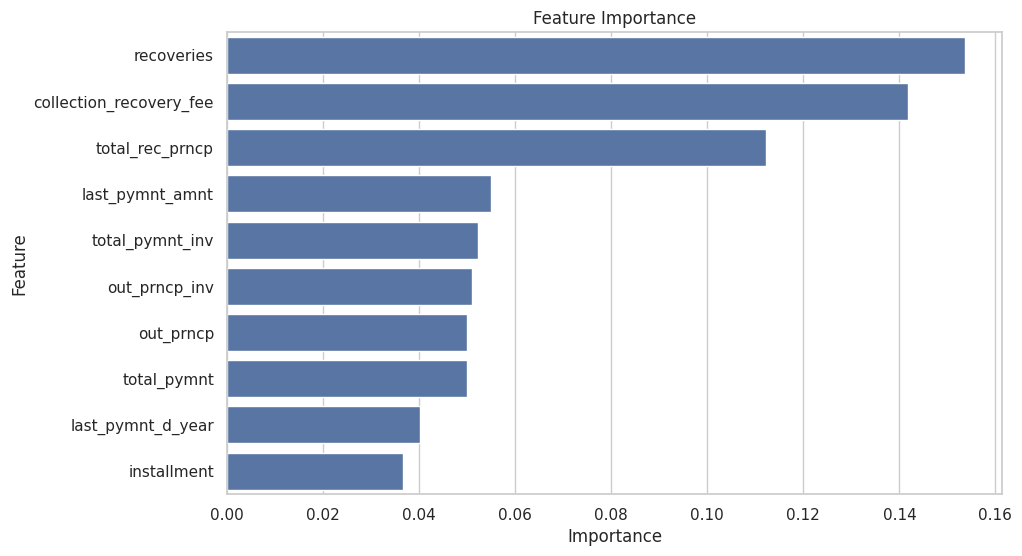

In [ ]:
feature_importance = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature':X.columns, 'Importance': feature_importance})
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title("Feature Importance")
plt.show()